# Coding Session 08 · Lab W8


## Reading polls and using survey weights

Read the supplied tables and intervals, explain why samples differ, and write a weighted mean. Most of the lab asks you to interpret supplied output; it does not ask you to build a survey package.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def load_data(filename):
    """Prefer a checkout; use the published repository in Colab."""
    relative = Path("wk08_trusting_polls") / "data" / filename
    candidates = [Path("data") / filename, relative]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path)
    return pd.read_csv("https://raw.githubusercontent.com/albertostefanelli/DSPC_coding_sessions/master/" + relative.as_posix())

## 1. Two pollsters, two samples

The phone and online CSVs are the lab's **teaching case data**, not verified releases from real pollsters. The age targets below are the population proportions supplied for that case. The later CES exercise uses actual survey observations and their supplied weights; keep the two sources separate.

Source: Joshua Kalla, [W8 course data](https://github.com/joshuakalla/data_science_campaigns_26/tree/main/weeks/wk08_trusting_polls/data), snapshot documented in [data provenance](https://github.com/albertostefanelli/DSPC_coding_sessions/blob/master/wk08_trusting_polls/data/README.md).

In [2]:
phone = load_data("phone_poll.csv")
online = load_data("online_poll.csv")
pop_age = pd.Series({"18-29": 0.180, "30-44": 0.250, "45-64": 0.321, "65+": 0.249})
assert np.isclose(pop_age.sum(), 1)
for frame in [phone, online]:
    assert frame["vote_intent"].isin(["dem", "rep", "undecided"]).all()
display(phone.head())
toplines = pd.DataFrame({
    "phone": phone["vote_intent"].value_counts(normalize=True),
    "online": online["vote_intent"].value_counts(normalize=True),
}).fillna(0)
display(toplines.round(3))

,respondent_id,age_group,vote_intent,poll
0,1,45-64,dem,phone_poll
1,2,30-44,dem,phone_poll
2,3,65+,rep,phone_poll
3,4,30-44,undecided,phone_poll
4,5,65+,dem,phone_poll


,phone,online
vote_intent,,
dem,0.462,0.509
rep,0.500,0.433
undecided,0.038,0.058


A candidate's **share** is one proportion. A **lead** subtracts the opponent's share. Score each respondent +1 for Dem, −1 for Rep, and 0 for undecided: the average score is the lead. Its uncertainty is larger than the conventional margin of error on one share.

The following approximation assumes independent respondents and simple random sampling. Mode differences and nonresponse are not included in these intervals.

In [3]:
def lead_summary(frame):
    score = frame["vote_intent"].map({"dem": 1, "rep": -1, "undecided": 0})
    lead = score.mean()
    se = score.std(ddof=1) / np.sqrt(len(score))
    return pd.Series({"n": len(score), "lead": lead, "se": se,
                      "low": lead - 1.96 * se, "high": lead + 1.96 * se,
                      "one_share_moe": 1.96 * np.sqrt(0.25 / len(score))})
lead_table = pd.DataFrame({"phone": lead_summary(phone), "online": lead_summary(online)}).T
display(lead_table.round(4))
gap = lead_table.loc["online", "lead"] - lead_table.loc["phone", "lead"]
se_gap = np.sqrt((lead_table["se"] ** 2).sum())
print("Difference between leads, pp:", round(100 * gap, 2))
print("Approximate independent-poll 95% interval, pp:",
      np.round(100 * np.array([gap - 1.96 * se_gap, gap + 1.96 * se_gap]), 2))

,n,lead,se,low,high,one_share_moe
phone,1001.0,-0.0390,0.0310,-0.0997,0.0218,0.031
online,1002.0,0.0758,0.0306,0.0159,0.1358,0.031


Difference between leads, pp: 11.48
Approximate independent-poll 95% interval, pp: [ 2.95 20.02]


**Read before continuing:** Does each lead interval contain zero? Does the interval for the **difference between polls** contain zero? A surprising disagreement under this simple model is reason to investigate composition and survey design. It does not identify which poll is correct or prove a particular source of bias.



## 2. Check composition, then construct age weights

Use labels to align the age groups before dividing. A group absent from the sample cannot be recovered just by making its weight larger.

,population,phone,online
18-29,0.180,0.060,0.333
30-44,0.250,0.170,0.308
45-64,0.321,0.359,0.245
65+,0.249,0.412,0.114


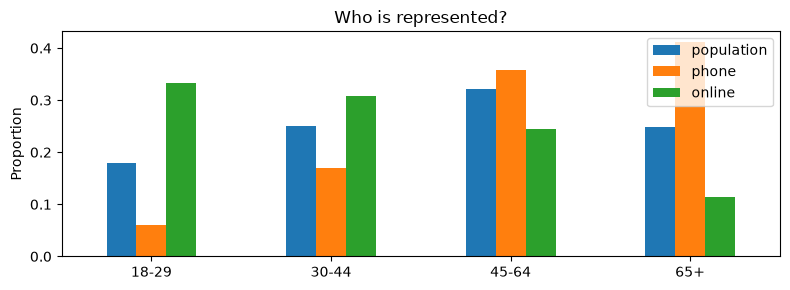

age_group
18-29    3.003000
30-44    1.472059
45-64    0.895045
65+      0.604973
Name: weight, dtype: float64

In [4]:
composition = pd.DataFrame({
    "population": pop_age,
    "phone": phone["age_group"].value_counts(normalize=True),
    "online": online["age_group"].value_counts(normalize=True),
}).reindex(pop_age.index)
display(composition.round(3))
composition.plot.bar(figsize=(8, 3), rot=0, ylabel="Proportion", title="Who is represented?")
plt.tight_layout()
plt.show()

def add_age_weights(frame):
    out = frame.copy()
    shares = out["age_group"].value_counts(normalize=True).reindex(pop_age.index)
    if shares.isna().any() or shares.le(0).any():
        raise ValueError("Every target age group must appear in the sample.")
    weights = pop_age / shares
    out["weight"] = out["age_group"].map(weights)
    if out["weight"].isna().any():
        raise ValueError("An age category is not in the target population.")
    out["is_dem"] = out["vote_intent"].eq("dem").astype(int)
    out["is_rep"] = out["vote_intent"].eq("rep").astype(int)
    return out
phone = add_age_weights(phone)
online = add_age_weights(online)
display(phone.groupby("age_group")["weight"].first())

## 3. Write the weighted mean

A weighted mean is **sum of outcome times weight, divided by sum of weights**. The denominator includes the same rows as the numerator. The toy example makes the arithmetic visible: a Dem respondent with weight 3 and a Rep respondent with weight 1 produce a Dem share of 3/4.

In [5]:
toy = pd.DataFrame({"is_dem": [1, 0], "weight": [3.0, 1.0]})
toy_mean = (toy["is_dem"] * toy["weight"]).sum() / toy["weight"].sum()
print("Toy weighted Dem share:", toy_mean)

Toy weighted Dem share: 0.75


**Your code:** In a new cell, write the weighted Dem and Rep means for `phone`, then their difference. Use the toy formula, not an unweighted `.mean()`. Repeat for `online` during further practice. Explain which composition problem age weighting addresses and which within-age nonresponse problem it cannot fix.



### Supplied precision diagnostic

Unequal weights usually reduce effective sample size. Kish's effective size below describes weight concentration. It is a diagnostic, not a complete survey-design variance estimator, and not proof that weighted estimates are unbiased.

In [6]:
def weight_diagnostics(frame):
    w = frame["weight"]
    effective_n = w.sum() ** 2 / (w ** 2).sum()
    return pd.Series({"rows": len(frame), "kish_effective_n": effective_n,
                      "weight_only_design_effect": len(frame) / effective_n})
display(pd.DataFrame({"phone": weight_diagnostics(phone),
                      "online": weight_diagnostics(online)}).T.round(2))
# Check that the constructed weights recover the target age composition.
weighted_age = phone.groupby("age_group")["weight"].sum() / phone["weight"].sum()
np.testing.assert_allclose(weighted_age.reindex(pop_age.index), pop_age)

,rows,kish_effective_n,weight_only_design_effect
phone,1001.0,743.41,1.35
online,1002.0,791.32,1.27


## 4. Transfer to actual CES respondents

This small extract contains **1,000 real respondents from the 2018 Cooperative Congressional Election Study**, now called the Cooperative Election Study. It comes from Shiro Kuriwaki's `cc18_samp` teaching sample and retains original pre-election party identification (`pid3`), birth year, and `commonweight`. We use the supplied common survey weight for the pre-election response, not a validated-voter weight.

| Column | Meaning |
| :--- | :--- |
| `case_id` | Original respondent identifier. |
| `birthyr` | Reported birth year. |
| `pid3` | 1 Democrat, 2 Republican, 3 Independent, 4 Other, 5 Not sure; 8 skipped and 9 not asked are excluded. |
| `commonweight` | Supplied common-content survey weight. |

Source: Schaffner, Ansolabehere, and Luks, [2018 CCES Common Content](https://doi.org/10.7910/DVN/ZSBZ7K); teaching sample distributed by [Shiro Kuriwaki](https://github.com/kuriwaki/ccesMRPprep/blob/main/R/datadoc_cces-common-samp.R).

This is a **weighted-mean exercise on a teaching subsample**, not a full-survey national estimate or an election forecast. Party identity is not vote intention. We do not construct these CES weights or claim that the lab's age targets apply to CES.

In [7]:
ces_raw = load_data("ces_2018_teaching_sample.csv")
ces = ces_raw.loc[
    ces_raw["pid3"].isin([1, 2, 3, 4, 5])
    & ces_raw["commonweight"].notna()
    & ces_raw["commonweight"].gt(0)
].copy()
ces["is_democrat"] = ces["pid3"].eq(1).astype(int)
ces["age_2018"] = 2018 - ces["birthyr"]
print("Source rows:", len(ces_raw), "Rows with a valid response and weight:", len(ces))
display(ces[["age_2018", "pid3", "commonweight"]].head())
print("Unweighted Democrat-identification share:", ces["is_democrat"].mean())

Source rows: 1000 Rows with a valid response and weight: 1000


,age_2018,pid3,commonweight
0,30,3,1.473967
1,78,2,1.332970
2,39,1,0.641233
3,72,2,1.348817
4,59,3,0.870063


Unweighted Democrat-identification share: 0.353


**Your code:** Write the weighted mean of `is_democrat` using `commonweight`. Compare it with the unweighted mean. Then multiply all weights by 10 and verify that the weighted mean stays the same. Do not treat respondents with missing or skipped party identification as non-Democrats.



## Further practice and interpretation

- Explain why larger sample size reduces sampling uncertainty without necessarily solving nonresponse bias.
- Use the supplied precision diagnostic to compare poll weights. Explain why matching age does not establish representative preferences within each age group.
- Read the two pollsters' arguments in the lab and identify which evidence would change your interpretation. Keep the lab's written ruling as your own work.



## Optional: a familiar DIME function and plot

The original finance data remain useful for reading, cleaning, categorizing, and plotting. This is an observational comparison: it does not show that changing a candidate's ideology causes a fundraising change. The earlier permutation/power prerequisites are covered in their matching earlier weeks.

,size,mean,median
ideology_group,,,
Outside threshold,2460,2406652.17,106251.06
Within threshold,201,1940172.76,216124.07


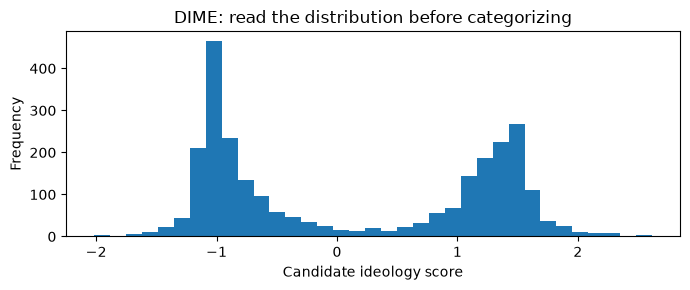

In [8]:
dime = load_data("dime_candidates_2020_2024_clean.csv")
def summarize_receipts(frame, threshold=0.5):
    clean = frame[["recipient.cfscore.dyn", "total.receipts"]].dropna().copy()
    clean["ideology_group"] = np.where(
        clean["recipient.cfscore.dyn"].abs() <= threshold, "Within threshold", "Outside threshold"
    )
    return clean.groupby("ideology_group")["total.receipts"].agg(["size", "mean", "median"])
display(summarize_receipts(dime).round(2))
ax = dime["recipient.cfscore.dyn"].dropna().plot.hist(bins=35, figsize=(7, 3))
ax.set(xlabel="Candidate ideology score", title="DIME: read the distribution before categorizing")
plt.tight_layout()
plt.show()

Source: Adam Bonica, [DIME](https://data.stanford.edu/dime), existing course extract. Compare the mean with the median before describing a typical candidate.

Restart the runtime and run all demonstration cells in order. Complete the weighted-mean exercises in separate cells and explain the tables in your own words.